<center><h1>combined-cycle-power-plant-data-analysis</h1></center>
<br>
<br>

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [13]:
import pandas as pd
import numpy as np
from scipy.io import arff
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

Get the Cycle Power Plant Data Set

In [14]:
ccpp_file = pd.read_excel('../data/CCPP/Folds5x2_pp.xlsx')
ccpp_file

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90
...,...,...,...,...,...
9563,16.65,49.69,1014.01,91.00,460.03
9564,13.19,39.18,1023.67,66.78,469.62
9565,31.32,74.33,1012.92,36.48,429.57
9566,24.48,69.45,1013.86,62.39,435.74


### (b) Exploring the data

#### i. rows and columns

In [15]:
ccpp_file
print(f"Rows : {len(ccpp_file)}")
print(f"Columns : {len(ccpp_file.columns)}")
print(f"Rows are data point  collected from a Combined Cycle Power Plant over 6 years (2006-2011)")
print(f"Columns consist of hourly average ambient variables Temperature (T), Ambient Pressure (AP), Relative Humidity (RH) and Exhaust Vacuum (V) to predict the net hourly electrical energy output (EP)  of the plant.")

Rows : 9568
Columns : 5
Rows are data point  collected from a Combined Cycle Power Plant over 6 years (2006-2011)
Columns consist of hourly average ambient variables Temperature (T), Ambient Pressure (AP), Relative Humidity (RH) and Exhaust Vacuum (V) to predict the net hourly electrical energy output (EP)  of the plant.


#### ii. pairwise scatterplots of all the varianbles

1.Energy output is correlated to the ambient variables Temperature and Exhaust Vacuum 
2.ambient variables Temperature is correlated to  Exhaust Vacuum 


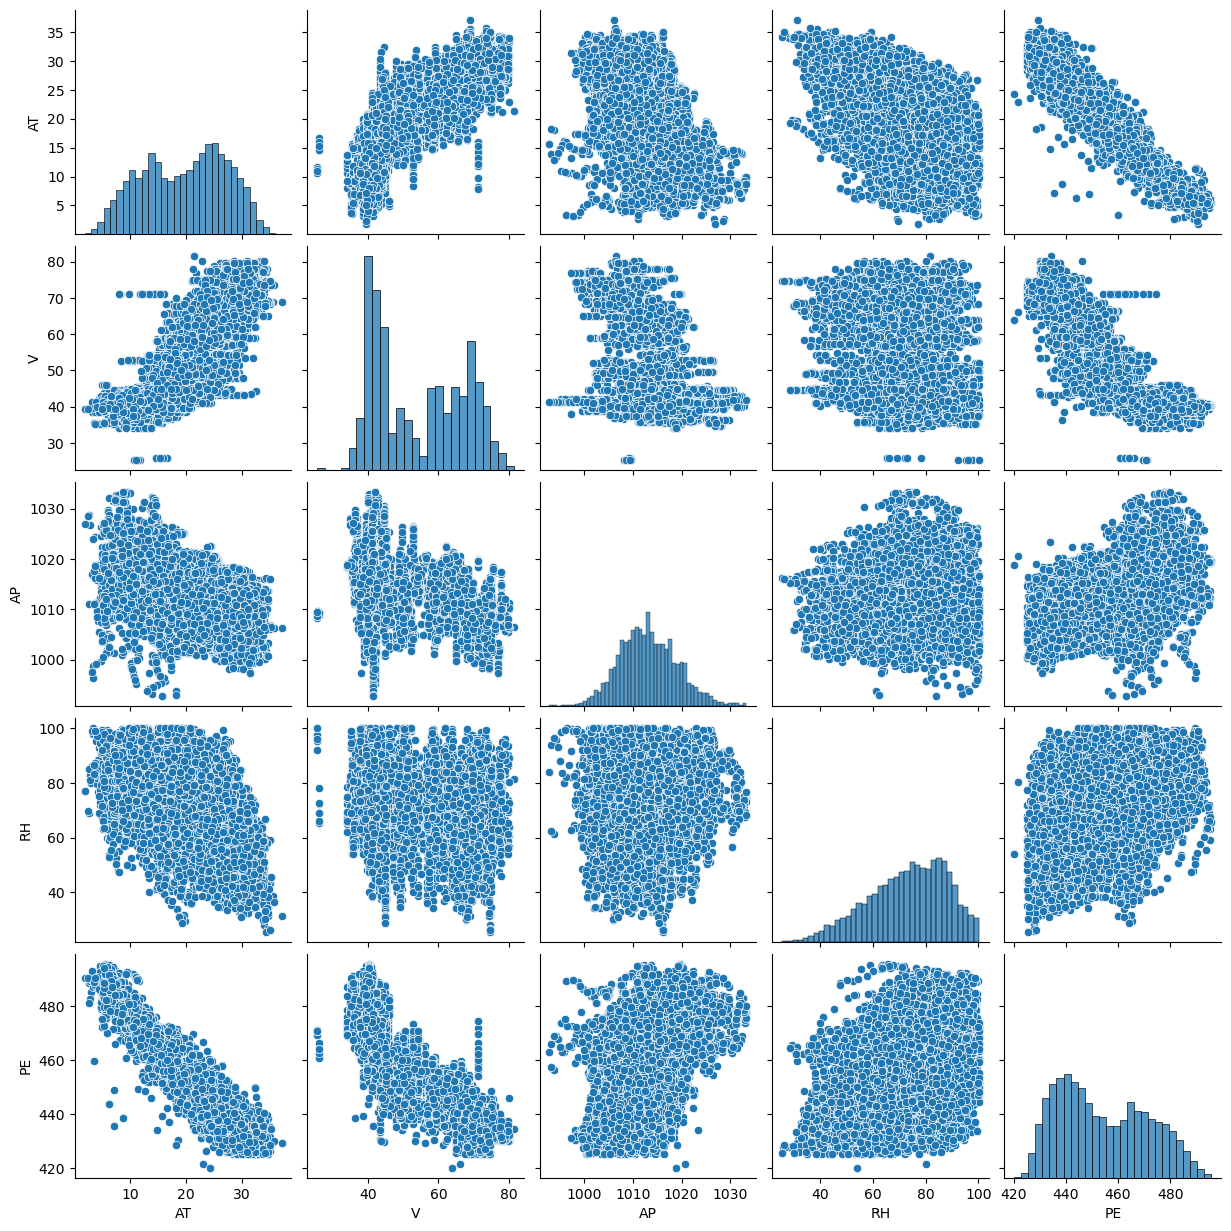

In [16]:
sns.pairplot(ccpp_file)
print("1.Energy output is correlated to the ambient variables Temperature and Exhaust Vacuum ")
print("2.ambient variables Temperature is correlated to  Exhaust Vacuum ")
plt.show()

#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [17]:
summary_table = pd.DataFrame({
    "Mean": ccpp_file.mean(),
    "Median": ccpp_file.median(),
    "Min": ccpp_file.min(),
    "Max": ccpp_file.max(),
})
summary_table["Range"] = summary_table["Max"]-summary_table["Min"]
summary_table["first_quartiles"] = ccpp_file.quantile(0.25)
summary_table["third_quartiles"] = ccpp_file.quantile(0.75)
summary_table["interquartile_quartiles"] = summary_table["third_quartiles"]-summary_table["first_quartiles"]
summary_table

,Mean,Median,Min,Max,Range,first_quartiles,third_quartiles,interquartile_quartiles
AT,19.651231,20.345,1.81,37.11,35.30,13.5100,25.72,12.2100
V,54.305804,52.080,25.36,81.56,56.20,41.7400,66.54,24.8000
AP,1013.259078,1012.940,992.89,1033.30,40.41,1009.1000,1017.26,8.1600
RH,73.308978,74.975,25.56,100.16,74.60,63.3275,84.83,21.5025
PE,454.365009,451.550,420.26,495.76,75.50,439.7500,468.43,28.6800


### (c) Simple Linear Regression

Observation: Energy output is strongly correlated to the ambient variables Temperature and Exhaust Vacuum 
Predictor: AT
Coefficient: -2.1713199585177843
Intercept: 497.03411989276657
R^2: 0.8989475964148236
----------------------------------------


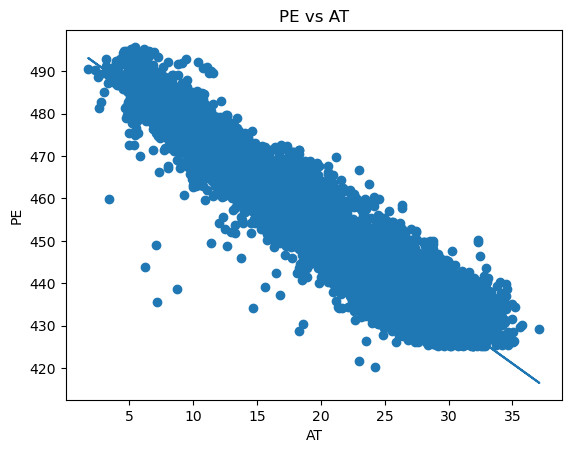

AT outlier indices: [15, 61, 87, 121, 140, 142, 199, 202, 222, 241, 297, 310, 317, 374, 418, 431, 437, 446, 452, 461, 464, 477, 480, 488, 495, 537, 542, 611, 631, 644, 647, 658, 665, 686, 705, 718, 728, 786, 808, 870, 887, 893, 901, 907, 930, 936, 955, 976, 1001, 1037, 1096, 1181, 1189, 1219, 1243, 1294, 1296, 1373, 1374, 1438, 1451, 1491, 1498, 1512, 1531, 1545, 1550, 1568, 1584, 1601, 1609, 1615, 1619, 1640, 1647, 1648, 1652, 1659, 1740, 1818, 1832, 1833, 1837, 1908, 1919, 1942, 1976, 2017, 2084, 2136, 2193, 2205, 2208, 2239, 2274, 2276, 2304, 2327, 2392, 2426, 2449, 2461, 2485, 2489, 2552, 2571, 2588, 2606, 2642, 2654, 2658, 2661, 2662, 2670, 2673, 2690, 2694, 2739, 2756, 2780, 2786, 2787, 2817, 2879, 2882, 2907, 2912, 2924, 2936, 3000, 3018, 3055, 3065, 3117, 3123, 3154, 3164, 3189, 3195, 3228, 3274, 3295, 3308, 3331, 3337, 3366, 3382, 3383, 3391, 3401, 3417, 3430, 3457, 3511, 3522, 3589, 3603, 3628, 3645, 3706, 3718, 3724, 3785, 3792, 3797, 3858, 3895, 3915, 3927, 3932, 3962, 3966

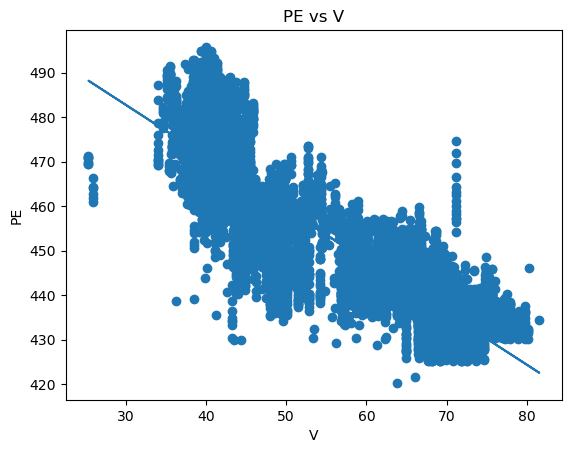

V outlier indices: [21, 24, 47, 57, 117, 153, 154, 172, 182, 199, 210, 317, 379, 380, 388, 405, 410, 440, 444, 459, 469, 473, 502, 511, 555, 570, 597, 606, 638, 662, 679, 682, 687, 690, 708, 775, 786, 806, 821, 830, 834, 848, 880, 885, 887, 907, 909, 943, 953, 956, 962, 973, 994, 1039, 1040, 1078, 1083, 1101, 1128, 1150, 1165, 1182, 1186, 1204, 1208, 1236, 1290, 1299, 1306, 1320, 1328, 1332, 1352, 1362, 1376, 1378, 1380, 1401, 1438, 1445, 1458, 1468, 1503, 1511, 1568, 1574, 1590, 1605, 1650, 1655, 1662, 1682, 1684, 1697, 1709, 1742, 1752, 1773, 1796, 1817, 1820, 1892, 1907, 1917, 1919, 1935, 1956, 1985, 2040, 2062, 2063, 2066, 2119, 2153, 2165, 2178, 2199, 2217, 2221, 2280, 2286, 2304, 2319, 2324, 2335, 2354, 2358, 2378, 2385, 2400, 2404, 2436, 2440, 2451, 2454, 2474, 2492, 2500, 2542, 2565, 2586, 2594, 2609, 2662, 2670, 2688, 2694, 2698, 2726, 2737, 2776, 2804, 2818, 2885, 2887, 2949, 2954, 2962, 2971, 2973, 2993, 3017, 3018, 3030, 3039, 3044, 3101, 3103, 3117, 3119, 3147, 3173, 3179,

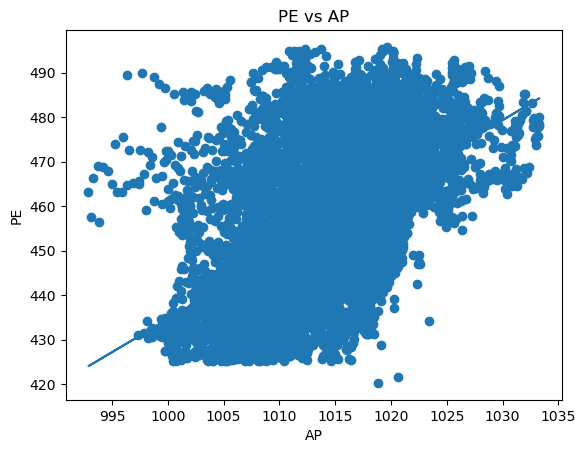

AP outlier indices: [2, 21, 22, 28, 57, 74, 154, 191, 199, 210, 252, 260, 329, 339, 410, 511, 513, 518, 521, 527, 555, 557, 597, 606, 608, 610, 614, 618, 638, 660, 680, 682, 690, 775, 789, 795, 847, 857, 882, 904, 960, 978, 983, 1060, 1091, 1111, 1115, 1129, 1172, 1220, 1285, 1290, 1315, 1320, 1323, 1332, 1337, 1392, 1405, 1437, 1449, 1468, 1481, 1490, 1511, 1593, 1598, 1615, 1621, 1628, 1650, 1662, 1674, 1675, 1718, 1735, 1796, 1850, 1899, 1907, 1936, 1945, 1967, 1975, 1996, 2003, 2018, 2023, 2047, 2085, 2100, 2118, 2151, 2153, 2165, 2170, 2221, 2250, 2262, 2372, 2451, 2500, 2535, 2542, 2572, 2688, 2726, 2776, 2799, 2838, 2885, 2916, 2951, 2972, 3048, 3089, 3100, 3101, 3148, 3188, 3189, 3267, 3311, 3348, 3363, 3418, 3424, 3425, 3442, 3452, 3481, 3496, 3509, 3531, 3637, 3666, 3684, 3714, 3750, 3752, 3758, 3783, 3814, 3818, 3834, 3868, 3883, 3894, 3895, 3899, 3914, 3919, 3958, 4002, 4011, 4013, 4029, 4067, 4080, 4116, 4136, 4168, 4186, 4193, 4218, 4230, 4238, 4330, 4338, 4367, 4375, 438

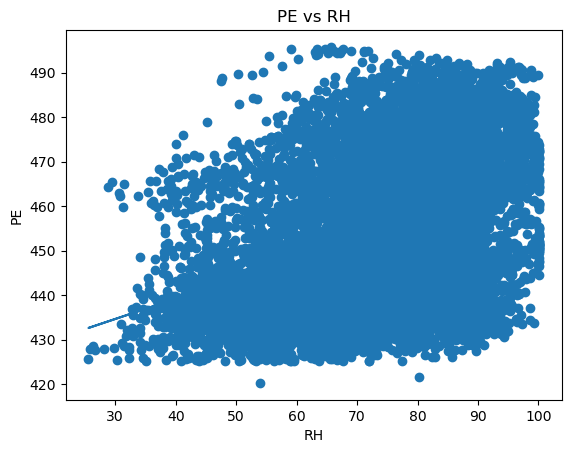

RH outlier indices: [8, 21, 199, 252, 310, 317, 421, 434, 490, 511, 606, 638, 707, 786, 806, 882, 887, 907, 953, 1067, 1174, 1285, 1361, 1511, 1518, 1601, 1609, 1705, 1715, 1981, 2022, 2083, 2084, 2199, 2221, 2304, 2330, 2358, 2404, 2407, 2449, 2504, 2530, 2594, 2600, 2641, 2662, 2670, 2687, 2688, 2694, 2776, 2841, 2885, 2887, 2950, 2971, 3018, 3044, 3089, 3101, 3144, 3188, 3189, 3248, 3258, 3343, 3402, 3411, 3496, 3522, 3525, 3557, 3594, 3605, 3637, 3673, 3714, 3724, 3752, 3757, 3758, 3834, 3839, 3850, 3868, 3875, 3935, 3970, 3999, 4086, 4105, 4193, 4218, 4310, 4415, 4504, 4607, 4702, 4719, 4742, 4754, 4799, 4907, 5049, 5084, 5117, 5188, 5218, 5238, 5245, 5258, 5333, 5387, 5402, 5426, 5482, 5498, 5564, 5629, 5644, 5703, 5708, 5789, 5812, 6031, 6036, 6203, 6233, 6293, 6389, 6514, 6516, 6555, 6628, 6668, 6720, 6810, 6814, 6818, 6922, 6968, 7009, 7276, 7284, 7313, 7327, 7422, 7467, 7473, 7589, 7712, 7727, 7846, 7864, 7866, 7879, 7900, 7931, 7944, 7951, 7956, 7962, 8071, 8076, 8105, 8122,

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

simple_results={}
simple_r2=[]
y = ccpp_file["PE"]
predictors = ccpp_file.columns.drop("PE")
print("Observation: Energy output is strongly correlated to the ambient variables Temperature and Exhaust Vacuum ")
for col in predictors:
    X = ccpp_file[[col]]  # must be 2D for sklearn
    model = LinearRegression()
    model.fit(X, y)
    
    y_pred = model.predict(X)
    
    r2 = r2_score(y, y_pred)
    simple_r2.append(r2)
    print(f"Predictor: {col}")
    print(f"Coefficient: {model.coef_[0]}")
    print(f"Intercept: {model.intercept_}")
    print(f"R^2: {r2}")
    simple_results[col] = {
    "coefficients": model.coef_,
    "intercept": model.intercept_,
    "R2": r2
    }
    print("-" * 40)
    plt.scatter(ccpp_file[col], y)
    plt.plot(ccpp_file[col], y_pred)
    plt.xlabel(col)
    plt.ylabel("PE")
    plt.title(f"PE vs {col}")
    # plt.savefig(f"../images/PE_{col}_Feature.png")
    plt.show()

    residuals = y - y_pred
    
    std_res = np.std(residuals)
    
    outliers = np.abs(residuals) > 2 * std_res
    
    
    print(f"{col} outlier indices:", ccpp_file.index[outliers].tolist())

### (d) Multiple Regression

In [19]:
import statsmodels.api as sm
y = ccpp_file["PE"]
predictors = ccpp_file.columns.drop("PE")
X = sm.add_constant(ccpp_file[predictors]) # do not force model pass through the (0,0)
model = sm.OLS(y, X).fit()

print("Every P-value of predictors are below 0.05; therefore, reject H0 : βj = 0 ")
print(model.summary())

Every P-value of predictors are below 0.05; therefore, reject H0 : βj = 0 
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Tue, 12 May 2026   Prob (F-statistic):               0.00
Time:                        15:26:05   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------

### (e) 1c Compare to 1d

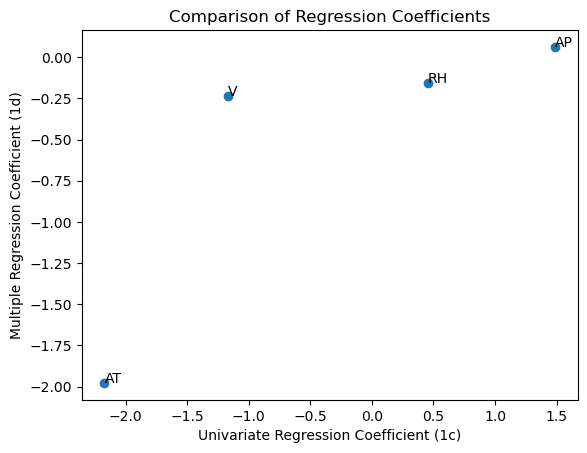

In [20]:
simple_coefs = {}
y = ccpp_file["PE"]
predictors = ccpp_file.columns.drop("PE")
#1c
for col in predictors:
    X = ccpp_file[[col]]   # 2D data
    model = LinearRegression()
    model.fit(X, y)
    simple_coefs[col] = model.coef_[0]



model = LinearRegression()
model.fit(ccpp_file[predictors], y)
multi_coefs = dict(zip(predictors, model.coef_)) # 

# plt.scatter(simple_coefs, multi_coefs)
# plt.xlabel("univariate regression coeﬃcients")
# plt.ylabel("multiple regression coeﬃcients")
# plt.title(f"univariate vs multiple ")
# plt.show()


x_vals = [simple_coefs[var] for var in predictors]
y_vals = [multi_coefs[var] for var in predictors]

plt.figure()
plt.scatter(x_vals, y_vals)

for i, var in enumerate(predictors):
    plt.text(x_vals[i], y_vals[i], var)


plt.xlabel("Univariate Regression Coefficient (1c)")
plt.ylabel("Multiple Regression Coefficient (1d)")
plt.title("Comparison of Regression Coefficients")

plt.savefig(f"../images/Comparison_of_Regression_Coefficients.png")

plt.show()



### (f) Nonlinear Association

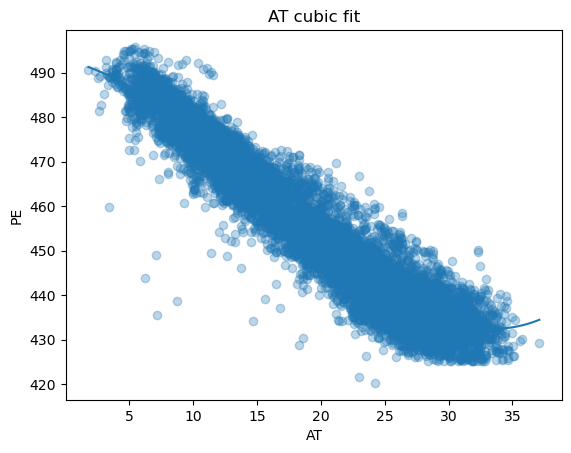

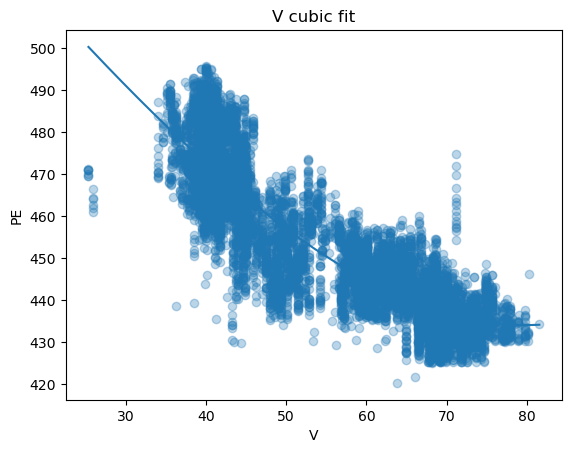

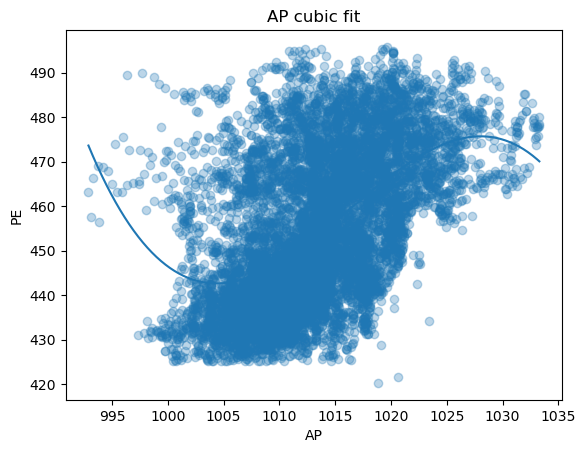

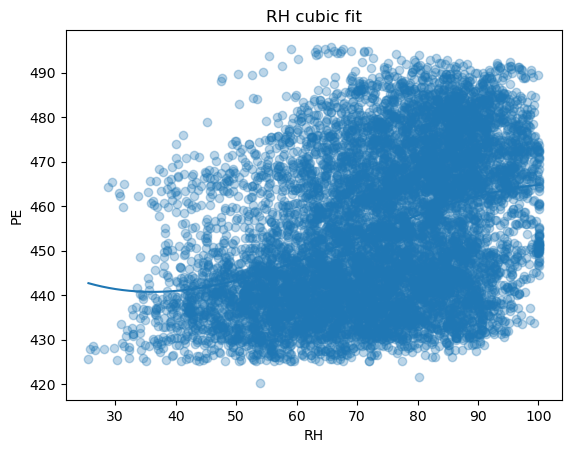

R2 gap :[0.012935066359448966, 0.018504190490544303, 0.028774809366372223, 0.001803095212284056]


In [21]:
from sklearn.preprocessing import PolynomialFeatures
cubic_results = {}
gap=[]
y = ccpp_file["PE"]
predictors = ccpp_file.columns.drop("PE")

for col in predictors:
    X = ccpp_file[[col]]
    
    poly = PolynomialFeatures(degree=3, include_bias=False)
    X_poly = poly.fit_transform(X)
    
    model = LinearRegression()
    model.fit(X_poly, y)
    
    y_pred = model.predict(X_poly)
    r2 = r2_score(y, y_pred)
    
    cubic_results[col] = {
        "coefficients": model.coef_,
        "intercept": model.intercept_,
        "R2": r2
    }

    gap.append(abs(cubic_results[col]["R2"]-simple_results[col]["R2"]))
    #  smooth curve
    # using same stream data for simple and cubic linear to see that β₂、β₃ are significant
    x_range = np.linspace(X.min(), X.max(), 200).reshape(-1,1)
    x_range_poly = poly.transform(x_range)
    y_range_pred = model.predict(x_range_poly)
    
    plt.figure()
    plt.scatter(X, y, alpha=0.3)
    plt.plot(x_range, y_range_pred)
    plt.xlabel(col)
    plt.ylabel("PE")
    plt.title(f"{col} cubic fit")
    
    plt.show()
    
   
print(f"R2 gap :{gap}")

### (g) Interactions of Predictors

In [22]:
import statsmodels.formula.api as smf

model = smf.ols(
    "PE ~ (AT + V + AP + RH)**4",
    data=ccpp_file
).fit()

print("Most of the intersaction are statistically significant due to P-value<0.05")
print(model.summary())




Most of the intersaction are statistically significant due to P-value<0.05
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.937
Method:                 Least Squares   F-statistic:                     9568.
Date:                Tue, 12 May 2026   Prob (F-statistic):               0.00
Time:                        15:26:05   Log-Likelihood:                -27450.
No. Observations:                9568   AIC:                         5.493e+04
Df Residuals:                    9552   BIC:                         5.505e+04
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------

### (h) Improvement_pairwise_interaction&quadratic terms 

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline
X = ccpp_file[predictors]
y = ccpp_file["PE"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

# splited_model
splited_model = LinearRegression()
splited_model.fit(X_train, y_train)

y_train_pred = splited_model.predict(X_train)
y_test_pred= splited_model.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

print("Splited_model Train MSE:", train_mse)
print("Splited_model Test MSE:", test_mse)


#splitted_inter_qua_model_pairwise

qua_model = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False), 
    LinearRegression()
)
qua_model.fit(X_train, y_train)

y_train_pred = qua_model.predict(X_train)
y_test_pred = qua_model.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

print("Splitted_inter_qua_model Train MSE:", train_mse)
print("Splitted_inter_qua_model Test MSE:", test_mse)


Splited_model Train MSE: 20.766119761450938
Splited_model Test MSE: 20.7774781068844
Splitted_inter_qua_model Train MSE: 18.059886723913706
Splitted_inter_qua_model Test MSE: 18.217100509037397


### (i) KNN

Raw features
Best k (CV): 6
Best CV MSE: 16.725460836285066
Final Train MSE: 11.276164128631395
Final Test MSE: 15.7511351658346

Scaled features
Best k (CV): 4
Best CV MSE: 15.474117442986858
Final Train MSE: 8.738516436464089
Final Test MSE: 14.070606067136888


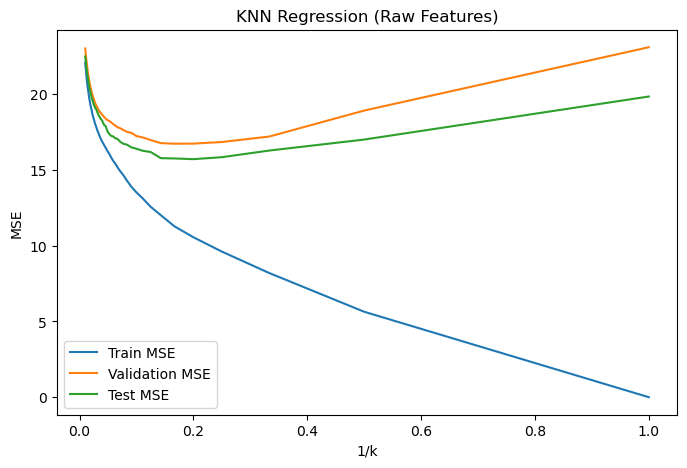

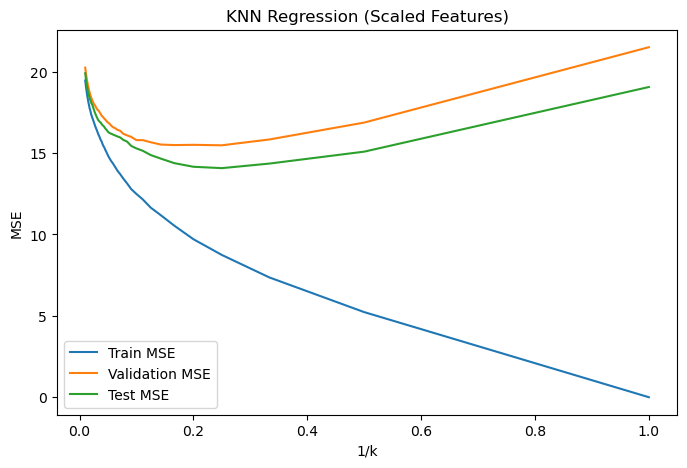

In [28]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Features and target
X = ccpp_file[predictors]
y = ccpp_file["PE"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

k_values = list(range(1, 101))
cv = KFold(n_splits=10, shuffle=True, random_state=1)

# ----------------------------
# 1) Raw features
# ----------------------------
train_mse_raw = []
test_mse_raw = []
cv_mse_raw = []

for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)

    # train/test MSE
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_mse_raw.append(mean_squared_error(y_train, y_train_pred))
    test_mse_raw.append(mean_squared_error(y_test, y_test_pred))

    # 10-fold CV MSE on training data
    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="neg_mean_squared_error",
        n_jobs=-1
    )
    cv_mse_raw.append(-cv_scores.mean())

best_k_raw_cv = k_values[np.argmin(cv_mse_raw)]
best_cv_mse_raw = min(cv_mse_raw)

# Refit final raw model using best k from CV
final_raw_model = KNeighborsRegressor(n_neighbors=best_k_raw_cv)
final_raw_model.fit(X_train, y_train)

final_train_pred_raw = final_raw_model.predict(X_train)
final_test_pred_raw = final_raw_model.predict(X_test)

final_train_mse_raw = mean_squared_error(y_train, final_train_pred_raw)
final_test_mse_raw = mean_squared_error(y_test, final_test_pred_raw)

print("Raw features")
print("Best k (CV):", best_k_raw_cv)
print("Best CV MSE:", best_cv_mse_raw)
print("Final Train MSE:", final_train_mse_raw)
print("Final Test MSE:", final_test_mse_raw)

# ----------------------------
# 2) Standardized features
# ----------------------------
train_mse_scaled = []
test_mse_scaled = []
cv_mse_scaled = []

for k in k_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=k))
    ])

    # train/test MSE
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_mse_scaled.append(mean_squared_error(y_train, y_train_pred))
    test_mse_scaled.append(mean_squared_error(y_test, y_test_pred))

    # 10-fold CV MSE on training data
    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="neg_mean_squared_error",
        n_jobs=-1
    )
    cv_mse_scaled.append(-cv_scores.mean())

best_k_scaled_cv = k_values[np.argmin(cv_mse_scaled)]
best_cv_mse_scaled = min(cv_mse_scaled)

# Refit final scaled model using best k from CV
final_scaled_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=best_k_scaled_cv))
])

final_scaled_model.fit(X_train, y_train)

final_train_pred_scaled = final_scaled_model.predict(X_train)
final_test_pred_scaled = final_scaled_model.predict(X_test)

final_train_mse_scaled = mean_squared_error(y_train, final_train_pred_scaled)
final_test_mse_scaled = mean_squared_error(y_test, final_test_pred_scaled)

print("\nScaled features")
print("Best k (CV):", best_k_scaled_cv)
print("Best CV MSE:", best_cv_mse_scaled)
print("Final Train MSE:", final_train_mse_scaled)
print("Final Test MSE:", final_test_mse_scaled)

# ----------------------------
# 3) Plot MSE vs 1/k
# ----------------------------
inv_k = [1 / k for k in k_values]

plt.figure(figsize=(8, 5))
plt.plot(inv_k, train_mse_raw, label="Train MSE")
plt.plot(inv_k, cv_mse_raw, label="Validation MSE")
plt.plot(inv_k, test_mse_raw, label="Test MSE")
plt.xlabel("1/k")
plt.ylabel("MSE")
plt.title("KNN Regression (Raw Features)")
plt.legend()
plt.savefig("../images/KNN_Regression_raw_results.png", bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(inv_k, train_mse_scaled, label="Train MSE")
plt.plot(inv_k, cv_mse_scaled, label="Validation MSE")
plt.plot(inv_k, test_mse_scaled, label="Test MSE")
plt.xlabel("1/k")
plt.ylabel("MSE")
plt.title("KNN Regression (Scaled Features)")
plt.legend()
plt.savefig("../images/KNN_Regression_scaled_results.png", bbox_inches="tight")
plt.show()